In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble        import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import RobustScaler
from sklearn.metrics         import (
    classification_report,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
np.random.seed(42)

In [2]:
DATASET_PATH = "/home/fyp_ids_e20/processed_dataset/balanced_application_data.csv"
LABEL_COLUMN = "Label"
BENIGN_LABEL = "Benign"

OUTPUT_DIR  = "/home/fyp_ids_e20/Eniyavan/Layer_models/layer2/step2"
MODELS_DIR  = "models"
RESULTS_DIR = os.path.join("results", "layer2")

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TEST_SIZE   = 0.20
VAL_SIZE    = 0.10
RANDOM_SEED = 42

# Isolation Forest
IF_N_ESTIMATORS  = 300
IF_MAX_SAMPLES   = 0.8
IF_CONTAMINATION = 0.01   # initial guess — overridden by threshold tuning

# Unknown class definition
UNKNOWN_FRACTION       = 0.10   # Option A: rarest 10% held out
UNKNOWN_ATTACK_CLASSES = []     # Option B: explicit list (overrides A)

APPLICATION_FEATURES = [
    "Pkt Size Avg",
    "Pkt Len Mean",
    "Pkt Len Max",
    "Pkt Len Min",
    "Pkt Len Std",
    "Pkt Len Var",
    "Fwd Pkt Len Max",
    "Fwd Pkt Len Min",
    "Fwd Pkt Len Mean",
    "Fwd Pkt Len Std",
    "Bwd Pkt Len Max",
    "Bwd Pkt Len Min",
    "Bwd Pkt Len Mean",
    "Bwd Pkt Len Std",
    "Fwd Seg Size Min",
    "Fwd Seg Size Avg",
    "Bwd Seg Size Avg",
    "TotLen Fwd Pkts",
    "Subflow Fwd Byts"
]

In [3]:
def load_dataset():
    df = pd.read_csv(DATASET_PATH, low_memory=False)
    df.columns       = df.columns.str.strip()
    df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.strip()

    total_rows  = len(df)
    benign_rows = (df[LABEL_COLUMN] == BENIGN_LABEL).sum()
    print(f"Total rows  : {total_rows:,}")
    print(f"Benign rows : {benign_rows:,}  (dropped — handled by Layer 1)")

    df_attacks = df[df[LABEL_COLUMN] != BENIGN_LABEL].copy().reset_index(drop=True)
    print(f"Attack rows : {len(df_attacks):,}  (kept)")

    found   = [f for f in APPLICATION_FEATURES if f in df_attacks.columns]
    missing = [f for f in APPLICATION_FEATURES if f not in df_attacks.columns]
    print(f"\nFeatures found   : {len(found)} / {len(APPLICATION_FEATURES)}")
    if missing: print(f"Features missing : {missing}")

    counts = df_attacks[LABEL_COLUMN].value_counts()
    print(f"\nAttack classes : {len(counts)}")
    for cls, cnt in counts.items():
        bar = chr(9608) * int(30 * cnt / counts.max())
        print(f"  {cls:<38}  {cnt:>8,}  {bar}")

    return df_attacks, counts, found

df_attacks, counts, found = load_dataset()

Total rows  : 6,870,587
Benign rows : 4,122,352  (dropped — handled by Layer 1)
Attack rows : 2,748,235  (kept)

Features found   : 19 / 19

Attack classes : 14
  DDOS attack-HOIC                         686,012  ██████████████████████████████
  DDoS attacks-LOIC-HTTP                   576,191  █████████████████████████
  DoS attacks-Hulk                         461,912  ████████████████████
  Bot                                      286,191  ████████████
  FTP-BruteForce                           193,360  ████████
  SSH-Bruteforce                           187,589  ████████
  Infilteration                            161,934  ███████
  DoS attacks-SlowHTTPTest                 139,890  ██████
  DoS attacks-GoldenEye                     41,508  █
  DoS attacks-Slowloris                     10,990  
  DDOS attack-LOIC-UDP                       1,730  
  Brute Force -Web                             611  
  Brute Force -XSS                             230  
  SQL Injection                  

In [4]:
def define_known_unknown(counts):
    all_classes = set(counts.index)

    if UNKNOWN_ATTACK_CLASSES:
        unknown_classes = set(UNKNOWN_ATTACK_CLASSES) & all_classes
        print("Mode: Option B — explicit list")
    elif UNKNOWN_FRACTION > 0:
        n_unk           = max(1, int(len(all_classes) * UNKNOWN_FRACTION))
        unknown_classes = set(counts.tail(n_unk).index)
        print(f"Mode: Option A — bottom {UNKNOWN_FRACTION*100:.0f}% -> {n_unk} unknown")
    else:
        unknown_classes = set()
        print("Mode: UNKNOWN_FRACTION=0 — all classes Known")

    known_classes = all_classes - unknown_classes

    print(f"\nKnown   ({len(known_classes)}):")
    for c in sorted(known_classes):   print(f"  +  {c:<40}  {counts.get(c,0):>8,} rows")
    print(f"\nUnknown ({len(unknown_classes)}):")
    for c in sorted(unknown_classes): print(f"  -  {c:<40}  {counts.get(c,0):>8,} rows")

    with open(os.path.join(MODELS_DIR,"layer2_known_classes.txt"),"w") as fh:
        for c in sorted(known_classes): fh.write(c+"\n")
    print(f"\nKnown class list saved -> {MODELS_DIR}/layer2_known_classes.txt")

    return known_classes, unknown_classes

known_classes, unknown_classes = define_known_unknown(counts)

Mode: Option A — bottom 10% -> 1 unknown

Known   (13):
  +  Bot                                        286,191 rows
  +  Brute Force -Web                               611 rows
  +  Brute Force -XSS                               230 rows
  +  DDOS attack-HOIC                           686,012 rows
  +  DDOS attack-LOIC-UDP                         1,730 rows
  +  DDoS attacks-LOIC-HTTP                     576,191 rows
  +  DoS attacks-GoldenEye                       41,508 rows
  +  DoS attacks-Hulk                           461,912 rows
  +  DoS attacks-SlowHTTPTest                   139,890 rows
  +  DoS attacks-Slowloris                       10,990 rows
  +  FTP-BruteForce                             193,360 rows
  +  Infilteration                              161,934 rows
  +  SSH-Bruteforce                             187,589 rows

Unknown (1):
  -  SQL Injection                                   87 rows

Known class list saved -> models/layer2_known_classes.txt


In [5]:
def prepare_data(df_attacks, known_classes, found):
    X = df_attacks[found].values.astype(np.float64)
    y = df_attacks[LABEL_COLUMN].isin(known_classes).astype(int).values

    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)
    val_frac = VAL_SIZE / (1.0 - TEST_SIZE)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_frac, random_state=RANDOM_SEED, stratify=y_tv)

    print(f"{'Split':<12} {'Total':>8}  {'Known':>8}  {'Unknown':>8}  {'Known%':>8}")
    print("-"*55)
    for name, X_, y_ in [("Train",X_train,y_train),("Validation",X_val,y_val),("Test",X_test,y_test)]:
        nk=(y_==1).sum(); nu=(y_==0).sum()
        print(f"{name:<12} {len(y_):>8,}  {nk:>8,}  {nu:>8,}  {100*nk/len(y_):>7.1f}%")

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df_attacks, known_classes, found)

Split           Total     Known   Unknown    Known%
-------------------------------------------------------
Train        1,923,764  1,923,703        61    100.0%
Validation    274,824   274,815         9    100.0%
Test          549,647   549,630        17    100.0%


In [6]:
def scale_features(X_train, X_val, X_test):
    scaler_path = os.path.join(MODELS_DIR, "/home/fyp_ids_e20/Eniyavan/Layer_models/layer1/models/layer1_scaler.pkl")
    if os.path.exists(scaler_path):
        scaler = joblib.load(scaler_path)
        print(f"Loaded Layer 1 scaler <- {scaler_path}")
    else:
        scaler = RobustScaler()
        scaler.fit(X_train)
        joblib.dump(scaler, os.path.join(MODELS_DIR,"/home/fyp_ids_e20/Eniyavan/Layer_models/layer1/models/layer1_scaler.pkl"))
        print("New RobustScaler fitted and saved.")

    return scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)

X_train_s, X_val_s, X_test_s = scale_features(X_train, X_val, X_test)
print(f"Train: {X_train_s.shape}  Val: {X_val_s.shape}  Test: {X_test_s.shape}")

Loaded Layer 1 scaler <- /home/fyp_ids_e20/Eniyavan/Layer_models/layer1/models/layer1_scaler.pkl
Train: (1923764, 19)  Val: (274824, 19)  Test: (549647, 19)


In [7]:
def train_isolation_forest(X_train_s, y_train):
    # ── Semi-supervised: keep Known rows only ─────────────────
    X_train_known = X_train_s[y_train == 1]
    print(f"Full train set      : {len(y_train):,} rows")
    print(f"Kept  (Known   = 1) : {len(X_train_known):,} rows  <- used for fitting")
    print(f"Dropped (Unknown=0) : {(y_train==0).sum():,} rows  <- withheld (unseen at train time)")

    iso_forest = IsolationForest(
        n_estimators  = IF_N_ESTIMATORS,
        max_samples   = IF_MAX_SAMPLES,
        contamination = IF_CONTAMINATION,
        random_state  = RANDOM_SEED,
        n_jobs        = -1,
    )
    print("\nTraining Isolation Forest...")
    t0 = time.time()
    iso_forest.fit(X_train_known)
    print(f"Done in {time.time()-t0:.1f}s")

    joblib.dump(iso_forest, os.path.join(MODELS_DIR,"layer2_isolation_forest.pkl"))
    print(f"Model saved -> {MODELS_DIR}/layer2_isolation_forest.pkl")
    return iso_forest

iso_forest = train_isolation_forest(X_train_s, y_train)

Full train set      : 1,923,764 rows
Kept  (Known   = 1) : 1,923,703 rows  <- used for fitting
Dropped (Unknown=0) : 61 rows  <- withheld (unseen at train time)

Training Isolation Forest...
Done in 45.2s
Model saved -> models/layer2_isolation_forest.pkl


Best threshold (val) : 0.737458
Best F1 (Unknown)    : 0.1429

Validation set preview:
              precision    recall  f1-score   support

     Unknown     0.2000    0.1111    0.1429         9
       Known     1.0000    1.0000    1.0000    274815

    accuracy                         1.0000    274824
   macro avg     0.6000    0.5555    0.5714    274824
weighted avg     0.9999    1.0000    1.0000    274824

Threshold saved -> models/layer2_threshold.txt


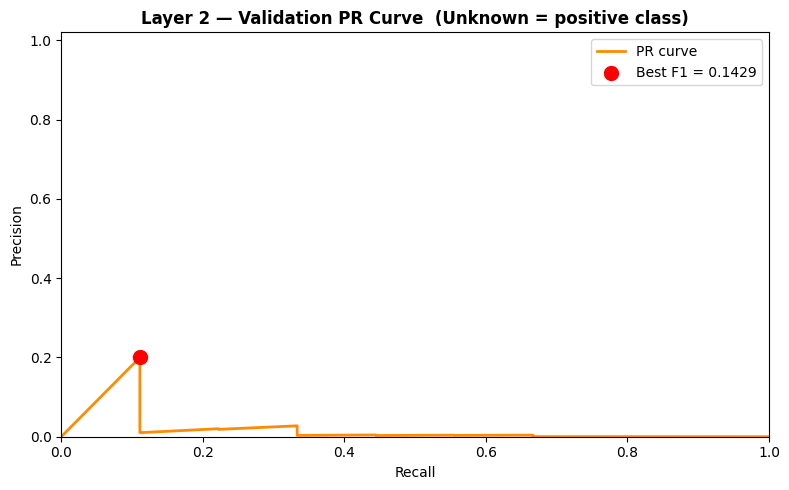

In [8]:
def tune_threshold(iso_forest, X_val_s, y_val):
    # score_samples: lower = more anomalous → invert
    val_anomaly_score = -iso_forest.score_samples(X_val_s)

    # Treat Unknown (0) as the positive class for tuning
    y_val_anomaly = (y_val == 0).astype(int)

    prec, rec, thresholds = precision_recall_curve(y_val_anomaly, val_anomaly_score)
    f1s      = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = int(np.argmax(f1s[:-1]))
    best_thr = float(thresholds[best_idx])
    best_f1  = float(f1s[best_idx])

    print(f"Best threshold (val) : {best_thr:.6f}")
    print(f"Best F1 (Unknown)    : {best_f1:.4f}")

    # Preview on validation set
    y_val_pred = np.where(val_anomaly_score >= best_thr, 0, 1)
    print("\nValidation set preview:")
    print(classification_report(y_val, y_val_pred,
          target_names=["Unknown","Known"], digits=4))

    with open(os.path.join(MODELS_DIR,"layer2_threshold.txt"),"w") as fh:
        fh.write(str(best_thr))
    print(f"Threshold saved -> {MODELS_DIR}/layer2_threshold.txt")

    # PR curve plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(rec[:-1], prec[:-1], color="darkorange", lw=2, label="PR curve")
    ax.scatter(rec[best_idx], prec[best_idx], color="red", s=100, zorder=5,
               label=f"Best F1 = {best_f1:.4f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Layer 2 — Validation PR Curve  (Unknown = positive class)",
                 fontweight="bold")
    ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,"layer2_val_pr_curve.png"),dpi=150,bbox_inches="tight")
    plt.show()

    return best_thr

best_threshold = tune_threshold(iso_forest, X_val_s, y_val)

In [9]:
def evaluate(iso_forest, X_test_s, y_test, best_threshold):
    # Steps 1-3: score, invert, threshold
    test_anomaly_score = -iso_forest.score_samples(X_test_s)
    y_pred = np.where(test_anomaly_score >= best_threshold, 0, 1)

    # PR-AUC — Unknown (0) as positive class
    y_test_anomaly = (y_test == 0).astype(int)
    pr_auc  = average_precision_score(y_test_anomaly, test_anomaly_score)
    try:    roc_auc = roc_auc_score(y_test_anomaly, test_anomaly_score)
    except: roc_auc = None

    print(f"PR-AUC  (Average Precision) : {pr_auc:.4f}")
    if roc_auc: print(f"ROC-AUC                     : {roc_auc:.4f}")

    print("\n" + "="*50)
    print("Isolation Forest — Test Set Classification Report")
    print("="*50)
    print(classification_report(y_test, y_pred,
          target_names=["Unknown","Known"], digits=4))

    return y_pred, test_anomaly_score

y_pred, test_anomaly_score = evaluate(iso_forest, X_test_s, y_test, best_threshold)

PR-AUC  (Average Precision) : 0.0208
ROC-AUC                     : 0.6601

Isolation Forest — Test Set Classification Report
              precision    recall  f1-score   support

     Unknown     0.1000    0.1176    0.1081        17
       Known     1.0000    1.0000    1.0000    549630

    accuracy                         0.9999    549647
   macro avg     0.5500    0.5588    0.5540    549647
weighted avg     0.9999    0.9999    0.9999    549647



In [10]:
def save_outputs(iso_forest, df_attacks, found, known_classes, unknown_classes, best_threshold):
    scaler_path = os.path.join(MODELS_DIR,"/home/fyp_ids_e20/Eniyavan/Layer_models/layer1/models/layer1_scaler.pkl")
    if not os.path.exists(scaler_path):
        scaler_path = os.path.join(MODELS_DIR,"layer2_scaler.pkl")
    scaler = joblib.load(scaler_path)

    X_all_s       = scaler.transform(df_attacks[found].values.astype(np.float64))
    all_anomaly   = -iso_forest.score_samples(X_all_s)
    pred_known    = all_anomaly < best_threshold
    pred_unknown  = ~pred_known

    df_known   = df_attacks[pred_known].copy().reset_index(drop=True)
    df_unknown = df_attacks[pred_unknown].copy().reset_index(drop=True)

    total = len(df_attacks)
    print(f"Total attack rows  : {total:,}")
    print(f"  -> Known   rows  : {len(df_known):,}  ({100*len(df_known)/total:.1f}%)  -> Layer 3")
    print(f"  -> Unknown rows  : {len(df_unknown):,}  ({100*len(df_unknown)/total:.1f}%)  -> Admin")

    known_csv   = os.path.join(OUTPUT_DIR,"known_attacks.csv")
    unknown_csv = os.path.join(OUTPUT_DIR,"unknown_attacks.csv")
    df_known.to_csv(known_csv,   index=False)
    df_unknown.to_csv(unknown_csv, index=False)
    print(f"\nknown_attacks.csv   -> {known_csv}")
    print(f"unknown_attacks.csv -> {unknown_csv}")

    cfg = {"routing_mode":"semi_supervised_isolation_forest",
           "threshold":best_threshold,"if_n_estimators":IF_N_ESTIMATORS,
           "known_classes":sorted(known_classes),"unknown_classes":sorted(unknown_classes),
           "known_attack_rows":int(len(df_known)),"unknown_attack_rows":int(len(df_unknown)),
           "label_column":LABEL_COLUMN,"features":found}
    with open(os.path.join(MODELS_DIR,"layer2_config.json"),"w") as fh:
        json.dump(cfg,fh,indent=2)
    print(f"Config saved -> {MODELS_DIR}/layer2_config.json")
    return df_known, df_unknown

df_known, df_unknown = save_outputs(iso_forest, df_attacks, found,
                                     known_classes, unknown_classes, best_threshold)

KeyboardInterrupt: 

In [ ]:
def generate_plots(iso_forest, X_test_s, y_test, y_pred, test_anomaly_score, best_threshold):
    y_test_anomaly = (y_test == 0).astype(int)

    # Plot 1 — Score distribution
    fig, ax = plt.subplots(figsize=(10,5))
    ax.hist(test_anomaly_score[y_test==1], bins=80, alpha=0.6,
            color="steelblue", density=True, label="Known (y=1)")
    ax.hist(test_anomaly_score[y_test==0], bins=80, alpha=0.6,
            color="tomato",    density=True, label="Unknown (y=0)")
    ax.axvline(best_threshold, color="black", linestyle="--", lw=2,
               label=f"Threshold = {best_threshold:.4f}")
    ax.set_xlabel("Anomaly Score  (higher = more anomalous)")
    ax.set_ylabel("Density")
    ax.set_title("Layer 2 — Anomaly Score Distribution", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,"layer2_score_distribution.png"),dpi=150,bbox_inches="tight")
    plt.show()

    # Plot 2 — Confusion matrix
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred),
                           display_labels=["Unknown","Known"]).plot(
        ax=ax, colorbar=True, cmap="Blues")
    ax.set_title("Layer 2 — Confusion Matrix (Test Set)",fontweight="bold",pad=10)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,"layer2_confusion_matrix.png"),dpi=150,bbox_inches="tight")
    plt.show()

    # Plot 3 — PR curve (test set)
    prec, rec, thr = precision_recall_curve(y_test_anomaly, test_anomaly_score)
    f1s    = 2*prec*rec/(prec+rec+1e-9)
    b_idx  = int(np.argmax(f1s[:-1]))
    pr_auc = average_precision_score(y_test_anomaly, test_anomaly_score)
    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(rec[:-1], prec[:-1], color="darkorange", lw=2,
            label=f"PR curve  (AP={pr_auc:.4f})")
    ax.scatter(rec[b_idx], prec[b_idx], color="red", s=100,
               zorder=5, label=f"Best F1={f1s[b_idx]:.4f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Layer 2 — PR Curve (Test Set)",fontweight="bold")
    ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,"layer2_pr_curve.png"),dpi=150,bbox_inches="tight")
    plt.show()

    # Plot 4 — ROC curve
    try:
        fpr,tpr,_ = roc_curve(y_test_anomaly, test_anomaly_score)
        roc_auc   = roc_auc_score(y_test_anomaly, test_anomaly_score)
        fig,ax = plt.subplots(figsize=(7,6))
        ax.plot(fpr,tpr,color="steelblue",lw=2,label=f"ROC (AUC={roc_auc:.4f})")
        ax.plot([0,1],[0,1],"k--",lw=1)
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
        ax.set_title("Layer 2 — ROC Curve (Test Set)",fontweight="bold")
        ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR,"layer2_roc_curve.png"),dpi=150,bbox_inches="tight")
        plt.show()
    except: print("ROC skipped.")

    # Plot 5 — PCA visualisation
    pca  = PCA(n_components=2, random_state=RANDOM_SEED)
    X2d  = pca.fit_transform(X_test_s)
    var  = pca.explained_variance_ratio_
    cmap_= {0:("Unknown","tomato"),1:("Known","steelblue")}
    fig, axes = plt.subplots(1,2,figsize=(14,6))
    for ax,(lbl,title) in zip(axes,[(y_test,"True Labels"),(y_pred,"IF Predictions")]):
        for cls,(cname,col) in cmap_.items():
            mask=(lbl==cls); ax.scatter(X2d[mask,0],X2d[mask,1],c=col,s=5,alpha=0.4,label=cname)
        ax.set_xlabel(f"PC1 ({100*var[0]:.1f}% var)")
        ax.set_ylabel(f"PC2 ({100*var[1]:.1f}% var)")
        ax.set_title(title,fontweight="bold"); ax.legend(markerscale=3)
    plt.suptitle("Layer 2 — PCA Visualisation (Test Set)",fontsize=13,fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,"layer2_pca_visualisation.png"),dpi=150,bbox_inches="tight")
    plt.show()
    print("All 5 plots saved.")

generate_plots(iso_forest, X_test_s, y_test, y_pred, test_anomaly_score, best_threshold)

In [ ]:
print("Layer 2 complete.")
print(f"  known_attacks.csv   : {len(df_known):,} rows  -> Layer 3")
print(f"  unknown_attacks.csv : {len(df_unknown):,} rows  -> Admin")
print("\nNext -> layer3_supervised_classifier.py")